# L10 — k-Space Encoding, Resolution, Gibbs Ringing & Aliasing

**Day 12 of the ROADMAP — MRI1 Lecture 10**

This notebook walks through the four main results of the lecture, hands-on:

1. **k-Space basics:** build a 2D image, FFT it, and see where contrast vs resolution live.
2. **Finite k_max → PSF is a sinc:** demonstrate the point spread function explicitly.
3. **Gibbs ringing:** show the ~9% overshoot that *won't go away* with higher $k_\text{max}$.
4. **Aliasing:** undersample in the phase direction and watch the image wrap.

Plus a bonus mini-experiment from **exercise 10.1** — the Hanning filter trade-off.

> **Time budget:** ~30 minutes if you run cell-by-cell. Modify parameters as you go; that's where the learning happens.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy.special import sici  # sine integral

# Display preferences
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['image.interpolation'] = 'nearest'

# Reproducibility
np.random.seed(42)

# Helpers we'll use a lot
def fft2c(img):
    """Centered 2D FFT — moves DC to the center."""
    return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

def ifft2c(kspace):
    """Centered 2D inverse FFT."""
    return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace)))

def kspace_log_mag(k):
    """Display k-space on a log scale (otherwise only the DC pixel is visible)."""
    return np.log(np.abs(k) + 1e-9)

print('Setup complete.')

Setup complete.


## 1. k-Space basics: build a phantom, look at its k-space

We'll build a simple Shepp-Logan-like brain phantom (manually, no external packages required) and look at its k-space.

<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:22: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/7r/8l6zv_k548ndcl244npwc2pr0000gn/T/ipykernel_8831/761318287.py:21: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax[0].imshow(phantom); ax[0].set_title('Phantom $S(\mathbf{r})$'); ax[0].axis('off')
/var/folders/7r/8l6zv_k548ndcl244npwc2pr0000gn/T/ipykernel_8831/76131

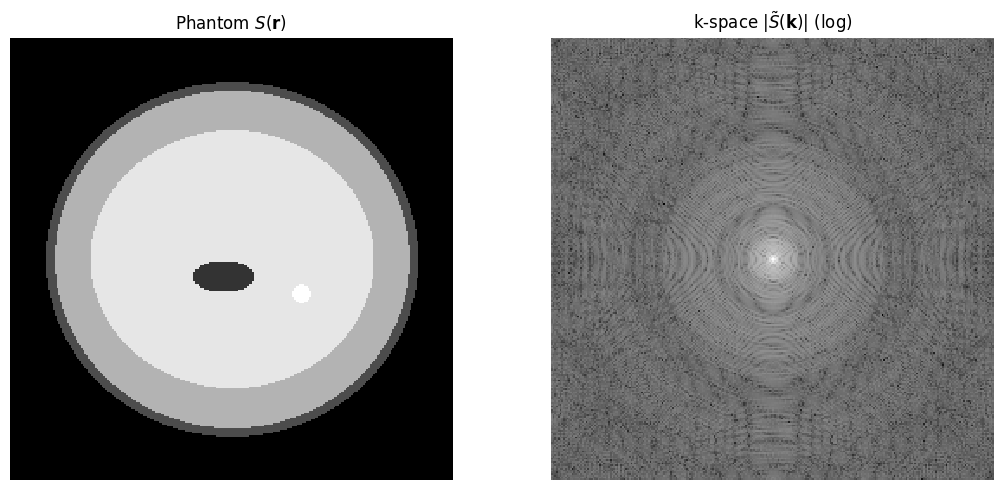

In [2]:
def make_phantom(N=256):
    """Hand-rolled brain-like phantom: skull, gray matter, ventricle, a tiny 'lesion'."""
    img = np.zeros((N, N))
    y, x = np.indices((N, N)) - N/2
    # outer skull
    img[(x**2 + (y*1.05)**2) < (N*0.42)**2] = 0.3
    # gray matter
    img[(x**2 + (y*1.05)**2) < (N*0.40)**2] = 0.7
    # white matter
    img[(x**2 + (y*1.10)**2) < (N*0.32)**2] = 0.9
    # ventricle
    img[((x+5)**2 + ((y-10)*2)**2) < (N*0.07)**2] = 0.2
    # small bright lesion
    img[((x-40)**2 + (y-20)**2) < (N*0.02)**2] = 1.0
    return img

phantom = make_phantom(256)
kspace = fft2c(phantom)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(phantom); ax[0].set_title('Phantom $S(\mathbf{r})$'); ax[0].axis('off')
ax[1].imshow(kspace_log_mag(kspace)); ax[1].set_title('k-space $|\\tilde S(\mathbf{k})|$ (log)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

**Notice:** almost all the energy lives at the **center** of k-space. The bright DC spike is the average image intensity. The outer regions look like noise but actually encode the *edges* of the phantom.

Let's prove the lecture's claim — *"center = contrast, edges = resolution"* — by masking k-space and reconstructing.

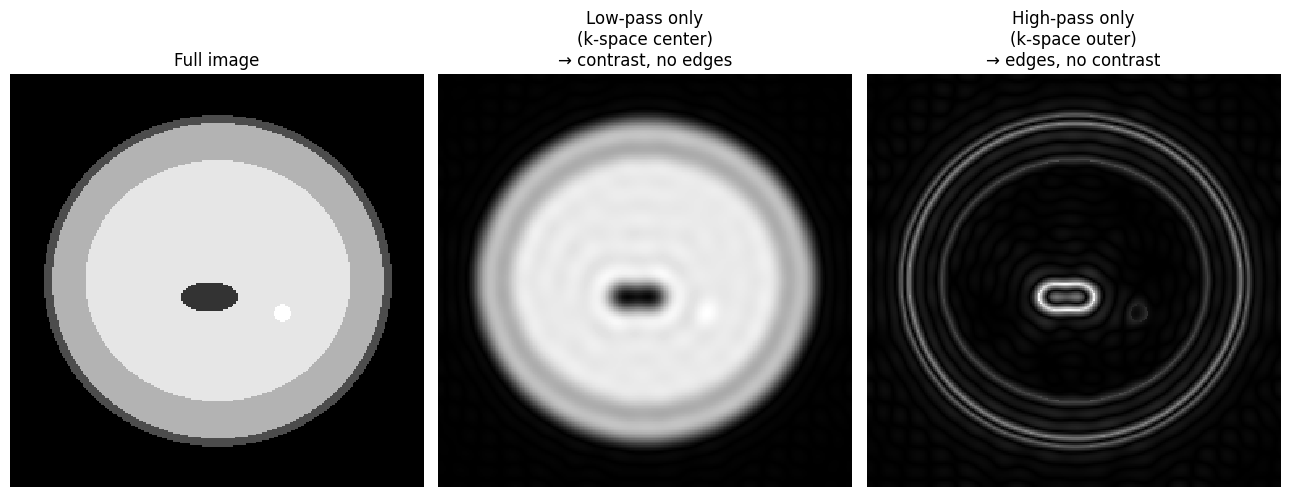

In [3]:
N = phantom.shape[0]
cy, cx = N//2, N//2
yy, xx = np.indices((N, N))
r = np.sqrt((xx-cx)**2 + (yy-cy)**2)

# (a) keep only the inner disk (low spatial frequencies)
mask_lowpass = (r < 15).astype(float)
img_low = np.abs(ifft2c(kspace * mask_lowpass))

# (b) keep only the outer ring (high spatial frequencies)
mask_highpass = (r >= 15).astype(float)
img_high = np.abs(ifft2c(kspace * mask_highpass))

fig, ax = plt.subplots(1, 3, figsize=(13, 5))
ax[0].imshow(phantom); ax[0].set_title('Full image'); ax[0].axis('off')
ax[1].imshow(img_low); ax[1].set_title('Low-pass only\n(k-space center)\n→ contrast, no edges'); ax[1].axis('off')
ax[2].imshow(img_high); ax[2].set_title('High-pass only\n(k-space outer)\n→ edges, no contrast'); ax[2].axis('off')
plt.tight_layout(); plt.show()

**This is the slide from the lecture, but built by you.** The center carries contrast (low-pass = blurry, but you can still see tissue types). The edges carry resolution (high-pass = only outlines, no fill).

**Try it:** change the radius `r < 15` to `r < 5` (extreme low-pass) or `r < 50` (mild low-pass) and watch what changes.

## 2. The PSF is a sinc — point-source demo

The lecture's key result: if you sample only $|\mathbf{k}| \le k_\text{max}$, the **point spread function** is a 2D sinc:

$$ T(\mathbf{r}) = (2 k_\text{max})^2 \, \text{sinc}(2\pi x \, k_\text{max}) \, \text{sinc}(2\pi y \, k_\text{max}) $$

Let's image a single point source through a finite-k-max Cartesian acquisition and see what comes out.

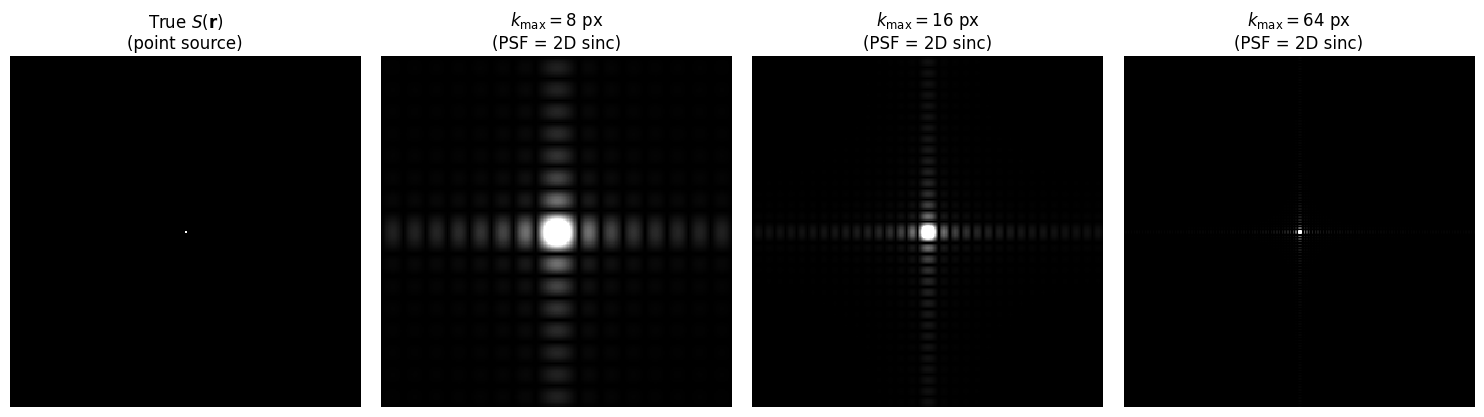

In [4]:
def acquire_with_kmax(img, kmax_pixels):
    """Simulate Cartesian sampling: zero out k-space outside a square of half-width kmax_pixels."""
    k = fft2c(img)
    N = img.shape[0]
    cy, cx = N//2, N//2
    mask = np.zeros_like(k)
    mask[cy-kmax_pixels:cy+kmax_pixels, cx-kmax_pixels:cx+kmax_pixels] = 1
    return np.abs(ifft2c(k * mask))

# Point source
N = 256
point_source = np.zeros((N, N))
point_source[N//2, N//2] = 1.0  # delta at the center

# Three different k_max values
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(point_source); ax[0].set_title('True $S(\\mathbf{r})$\n(point source)'); ax[0].axis('off')

for i, kmax in enumerate([8, 16, 64]):
    img_recon = acquire_with_kmax(point_source, kmax)
    ax[i+1].imshow(img_recon, vmax=img_recon.max()*0.5)  # boost low-amplitude rings
    ax[i+1].set_title(f'$k_\\text{{max}} = {kmax}$ px\n(PSF = 2D sinc)')
    ax[i+1].axis('off')

plt.tight_layout(); plt.show()

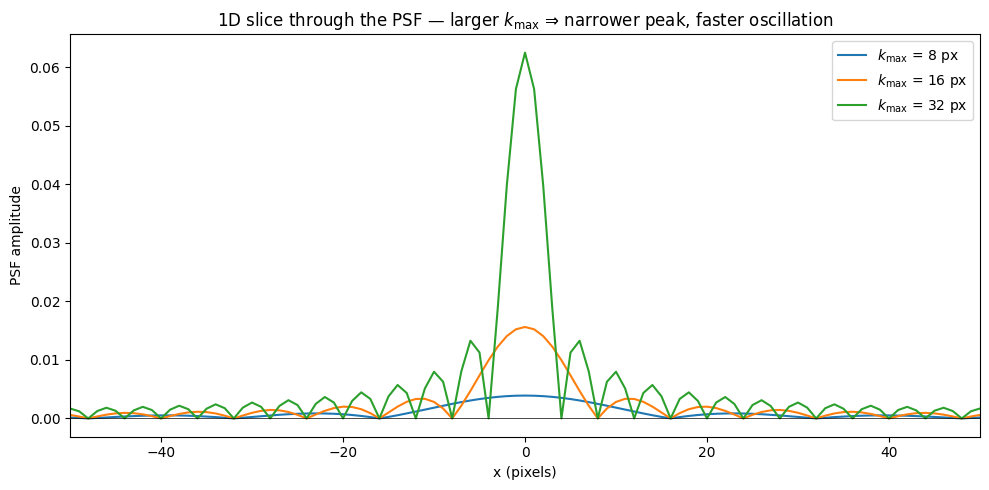

In [5]:
# Same thing in 1D, more quantitatively — overlay several k_max values
x = np.arange(-128, 128)

fig, ax = plt.subplots(figsize=(10, 5))
for kmax_px, color in [(8, 'tab:blue'), (16, 'tab:orange'), (32, 'tab:green')]:
    psf_row = acquire_with_kmax(point_source, kmax_px)[N//2, :]
    ax.plot(x, psf_row, color=color, label=f'$k_\\text{{max}}$ = {kmax_px} px')

ax.set_xlim(-50, 50)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('x (pixels)')
ax.set_ylabel('PSF amplitude')
ax.set_title('1D slice through the PSF — larger $k_\\text{max}$ ⇒ narrower peak, faster oscillation')
ax.legend()
plt.tight_layout(); plt.show()

Observe the three things the lecture predicts:
1. **Narrower central peak** as $k_\text{max}$ increases (better resolution).
2. **Faster oscillation** of the side lobes.
3. **Side lobes still ring out** — they drop as $1/x$, not exponentially. Even at high $k_\text{max}$ the tail is *spatially compressed*, not eliminated.

Now let's nail down the three definitions of "resolution".

## Three definitions of resolution — same PSF, different answers

For $T(x) = 2 k_\text{max} \, \text{sinc}(2\pi x \, k_\text{max})$:

| Definition | Formula | Value for sinc PSF |
|---|---|---|
| 1 — first zero crossing | $T(\Delta x)=0$ | $\Delta x = 1/(2k_\text{max})$ |
| 2 — area / height | $\Delta x = \int T(x) dx / T(0)$ | $\Delta x = 1/(2k_\text{max})$ |
| 3 — FWHM | $0.5 T(0) = T(\Delta x/2)$ | $\Delta x \approx 1/(1.65 k_\text{max})$ |

Let's compute all three numerically and confirm.

For k_max = 2.0 mm^-1:
  Def 1 (first zero):      Δx = 0.2500 mm   [theory: 1/(2·k_max) = 0.2500]
  Def 2 (area / height):   Δx = 0.2437 mm   [theory: 1/(2·k_max) = 0.2500]
  Def 3 (FWHM):            Δx = 0.3020 mm   [theory: ≈ 1/(1.65·k_max) = 0.3030]


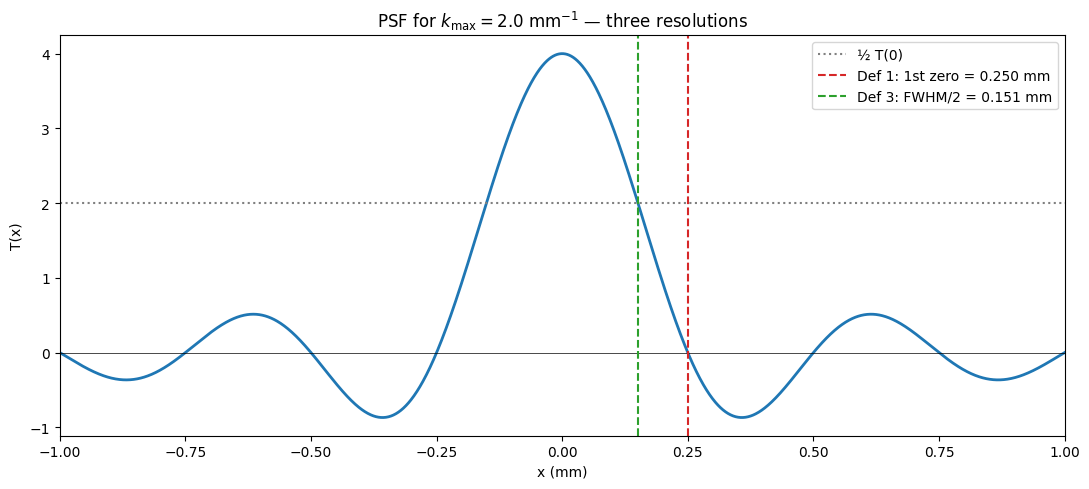

In [6]:
# Analytic sinc PSF (continuous), in physical units (mm)
kmax_inv_mm = 2.0           # 2 mm^-1 — typical for a high-res scan
x_mm = np.linspace(-2, 2, 4001)
T = 2*kmax_inv_mm * np.sinc(2 * x_mm * kmax_inv_mm)  # np.sinc(z) = sin(πz)/(πz), so np.sinc(2 x kmax) = sinc(2π x kmax) by our convention

# Definition 1: first zero crossing
# np.sinc(z) = 0 when z is a nonzero integer, so 2 x kmax = 1 → x = 1/(2 kmax)
delta_x_def1 = 1 / (2 * kmax_inv_mm)

# Definition 2: integral / height (numerical)
delta_x_def2 = np.trapezoid(T, x_mm) / T[len(T)//2]

# Definition 3: FWHM (numerical)
# Find the rightmost point where T crosses 0.5 * T(0)
T0 = T[len(T)//2]
half = 0.5 * T0
right_half = x_mm[len(x_mm)//2:]
T_right = T[len(T)//2:]
idx = np.where(T_right < half)[0][0]
x_half = right_half[idx]
fwhm = 2 * x_half
delta_x_def3 = fwhm

print(f'For k_max = {kmax_inv_mm} mm^-1:')
print(f'  Def 1 (first zero):      Δx = {delta_x_def1:.4f} mm   [theory: 1/(2·k_max) = {1/(2*kmax_inv_mm):.4f}]')
print(f'  Def 2 (area / height):   Δx = {delta_x_def2:.4f} mm   [theory: 1/(2·k_max) = {1/(2*kmax_inv_mm):.4f}]')
print(f'  Def 3 (FWHM):            Δx = {delta_x_def3:.4f} mm   [theory: ≈ 1/(1.65·k_max) = {1/(1.65*kmax_inv_mm):.4f}]')

# Plot with annotations
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x_mm, T, lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.axhline(half, color='gray', ls=':', label='½ T(0)')
ax.axvline(delta_x_def1, color='tab:red', ls='--', label=f'Def 1: 1st zero = {delta_x_def1:.3f} mm')
ax.axvline(delta_x_def3/2, color='tab:green', ls='--', label=f'Def 3: FWHM/2 = {delta_x_def3/2:.3f} mm')
ax.set_xlim(-1, 1)
ax.set_xlabel('x (mm)'); ax.set_ylabel('T(x)')
ax.set_title(f'PSF for $k_\\text{{max}} = {kmax_inv_mm}$ mm$^{{-1}}$ — three resolutions')
ax.legend()
plt.tight_layout(); plt.show()

**Sanity check:** Definitions 1 and 2 agree exactly (both give $1/(2 k_\text{max}) = 0.25$ mm). Definition 3 gives a slightly larger number (~0.30 mm) because the FWHM is wider than the first-zero distance. The lecture's numerical value $1/(1.65 k_\text{max})$ is reproduced.

## 3. Gibbs ringing — the ~9% overshoot that won't die

The lecture's analytic result for the sinc-convolved Heaviside:

$$ S_\text{MRI}(x) = \frac{S_0}{\pi} \left( \frac{\pi}{2} + \mathrm{Si}(2\pi k_\text{max} x) \right) $$

where $\mathrm{Si}(y) = \int_0^y \mathrm{sinc}(y')\,dy'$. Let's plot this for three $k_\text{max}$ values and observe the constant ~9% overshoot.

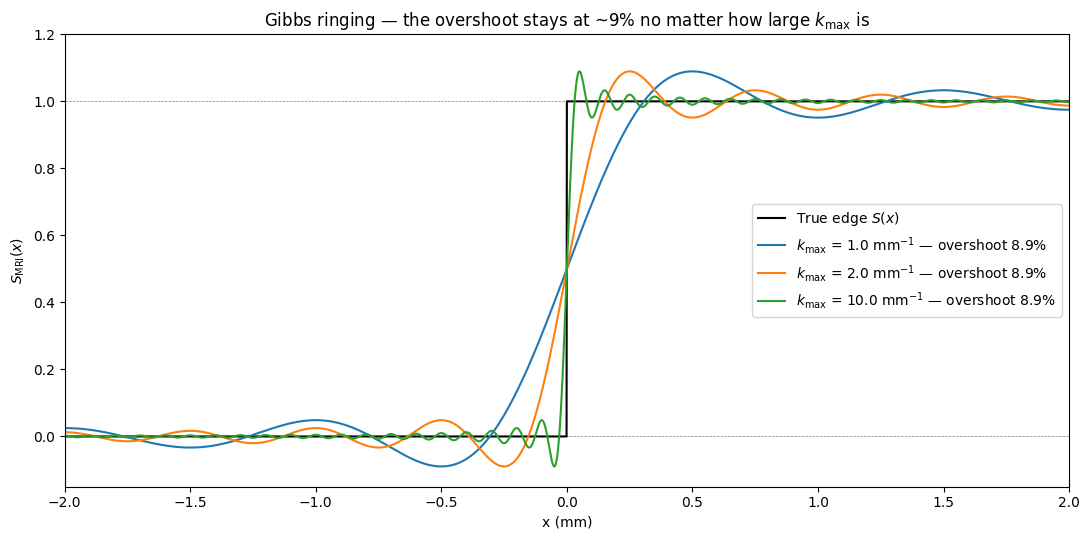

In [7]:
# scipy's sici returns (Si(x), Ci(x)) but uses sin(t)/t in its integrand, not sin(πt)/(πt).
# By substitution: ∫_0^{2π k_max x} sin(t)/t dt = ∫_0^{2π k_max x} sinc(t/π) dt where 'sinc' here is sin(t)/t.
# Our slide uses sinc(y) = sin(πy)/(πy), so Si(2π k_max x) in the slide = scipy's Si(2π k_max x).

S0 = 1.0
x = np.linspace(-2.5, 2.5, 4001)  # mm

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axhline(1, color='k', lw=0.5, ls='--', alpha=0.5)
ax.axhline(0, color='k', lw=0.5, ls='--', alpha=0.5)

# True edge
ideal = (x >= 0).astype(float)
ax.plot(x, ideal, 'k', lw=1.5, label='True edge $S(x)$')

for kmax_inv_mm in [1.0, 2.0, 10.0]:
    Si, _ = sici(2 * np.pi * kmax_inv_mm * x)
    S_mri = (S0 / np.pi) * (np.pi/2 + Si)
    overshoot = (S_mri.max() - 1.0) * 100
    ax.plot(x, S_mri, lw=1.5, label=f'$k_\\text{{max}}$ = {kmax_inv_mm} mm$^{{-1}}$ — overshoot {overshoot:.1f}%')

ax.set_xlim(-2, 2); ax.set_ylim(-0.15, 1.2)
ax.set_xlabel('x (mm)'); ax.set_ylabel('$S_\\text{MRI}(x)$')
ax.set_title('Gibbs ringing — the overshoot stays at ~9% no matter how large $k_\\text{max}$ is')
ax.legend()
plt.tight_layout(); plt.show()

All three curves overshoot by **the same ~9%**. Larger $k_\text{max}$ compresses the ringing spatially, but the *amplitude* of the overshoot is a topological feature of truncating Fourier series — you can't beat it without changing the strategy (e.g. apply a filter).

### Gibbs ringing in 2D — on a real(ish) phantom

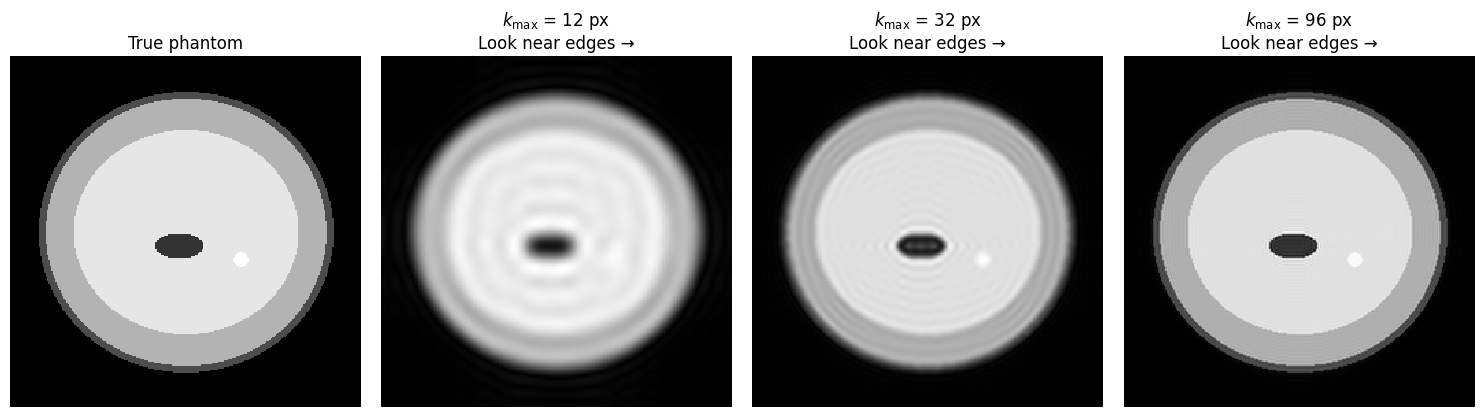

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(phantom); ax[0].set_title('True phantom'); ax[0].axis('off')

for i, kmax in enumerate([12, 32, 96]):
    recon = acquire_with_kmax(phantom, kmax)
    ax[i+1].imshow(recon); ax[i+1].set_title(f'$k_\\text{{max}}$ = {kmax} px\nLook near edges →'); ax[i+1].axis('off')

plt.tight_layout(); plt.show()

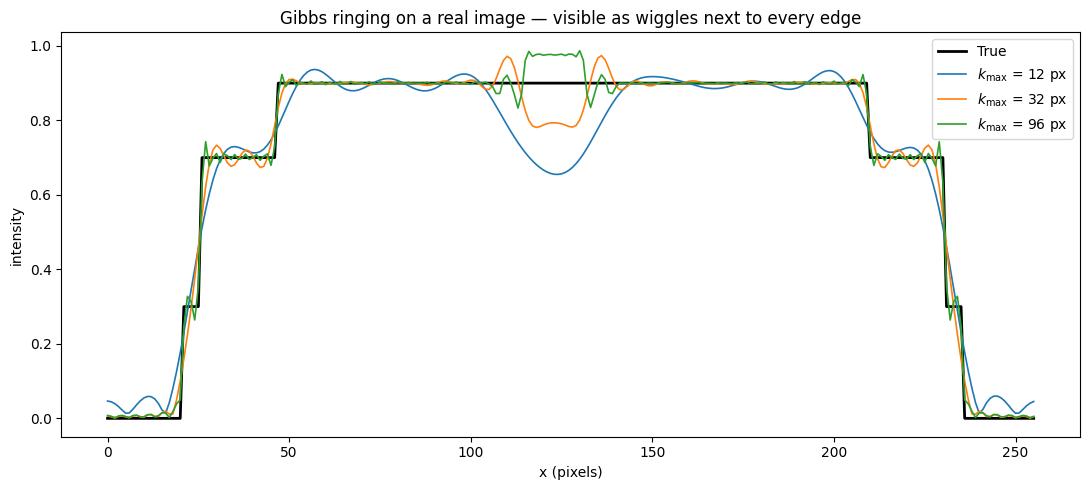

In [9]:
# Look at the ringing along a horizontal line through the phantom
row = phantom.shape[0] // 2
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(phantom[row], 'k', lw=2, label='True')
for kmax, c in [(12, 'tab:blue'), (32, 'tab:orange'), (96, 'tab:green')]:
    recon = acquire_with_kmax(phantom, kmax)
    ax.plot(recon[row], color=c, lw=1.2, label=f'$k_\\text{{max}}$ = {kmax} px')
ax.set_xlabel('x (pixels)'); ax.set_ylabel('intensity')
ax.set_title('Gibbs ringing on a real image — visible as wiggles next to every edge')
ax.legend()
plt.tight_layout(); plt.show()

**Clinical relevance:** in spinal cord imaging or near the skull-brain boundary, Gibbs ringing can produce dark or bright bands that **look like real lesions**. Modern diffusion MRI pipelines often run a Gibbs-suppression step (e.g. Kellner et al., *Magn. Reson. Med.* 2016) before quantitative analysis.

### Exercise 10.1 — Hanning filter trade-off

Apply the Hanning filter $\tilde F_\text{Hanning}(k) = 0.5 (1 + \cos(\pi k / k_\text{max}))$ and see ringing reduce *and* resolution worsen.

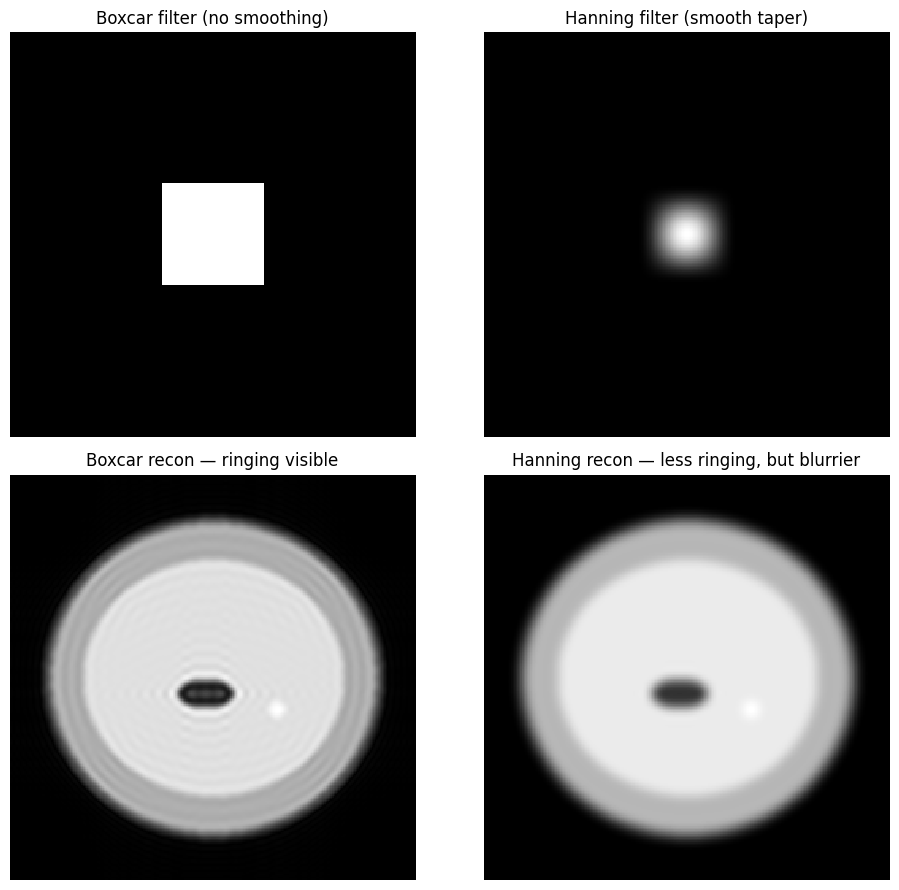

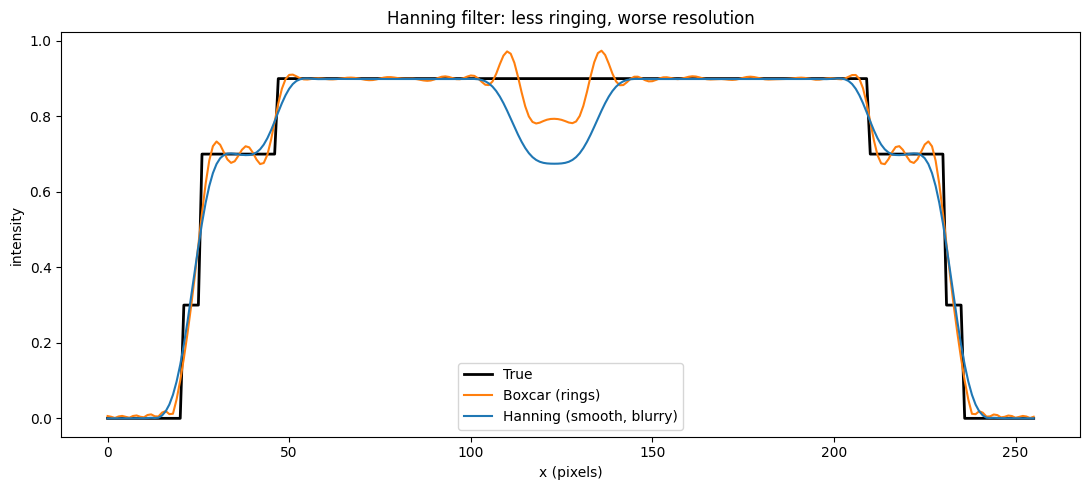

In [10]:
def hanning_filter_2d(N, kmax_pixels):
    """2D separable Hanning filter that lives inside |k| <= kmax_pixels."""
    k1d = np.linspace(-1, 1, 2*kmax_pixels)  # normalized to [-1, 1]
    han_1d = 0.5 * (1 + np.cos(np.pi * k1d))
    han_2d = np.outer(han_1d, han_1d)
    full = np.zeros((N, N))
    c = N // 2
    full[c-kmax_pixels:c+kmax_pixels, c-kmax_pixels:c+kmax_pixels] = han_2d
    return full

def acquire_filtered(img, kmax_pixels, filter_2d):
    k = fft2c(img)
    return np.abs(ifft2c(k * filter_2d))

N = phantom.shape[0]
kmax = 32

boxcar = np.zeros((N, N))
boxcar[N//2-kmax:N//2+kmax, N//2-kmax:N//2+kmax] = 1
hanning = hanning_filter_2d(N, kmax)

recon_box = acquire_filtered(phantom, kmax, boxcar)
recon_han = acquire_filtered(phantom, kmax, hanning)

fig, ax = plt.subplots(2, 2, figsize=(10, 9))
ax[0,0].imshow(boxcar); ax[0,0].set_title('Boxcar filter (no smoothing)'); ax[0,0].axis('off')
ax[0,1].imshow(hanning); ax[0,1].set_title('Hanning filter (smooth taper)'); ax[0,1].axis('off')
ax[1,0].imshow(recon_box); ax[1,0].set_title('Boxcar recon — ringing visible'); ax[1,0].axis('off')
ax[1,1].imshow(recon_han); ax[1,1].set_title('Hanning recon — less ringing, but blurrier'); ax[1,1].axis('off')
plt.tight_layout(); plt.show()

# 1D comparison through the middle
row = N // 2
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(phantom[row], 'k', lw=2, label='True')
ax.plot(recon_box[row], 'tab:orange', lw=1.5, label='Boxcar (rings)')
ax.plot(recon_han[row], 'tab:blue', lw=1.5, label='Hanning (smooth, blurry)')
ax.set_xlabel('x (pixels)'); ax.set_ylabel('intensity')
ax.set_title('Hanning filter: less ringing, worse resolution')
ax.legend()
plt.tight_layout(); plt.show()

## 4. Aliasing / wrap-around

Now we shift attention to the **other** limitation: discrete sampling in the phase direction. Spacing $\Delta k$ in k-space → image is replicated with period $1/\Delta k$ = **field of view**.

**Demonstration:** undersample k-space in the vertical (phase) direction by keeping only every Nth line.

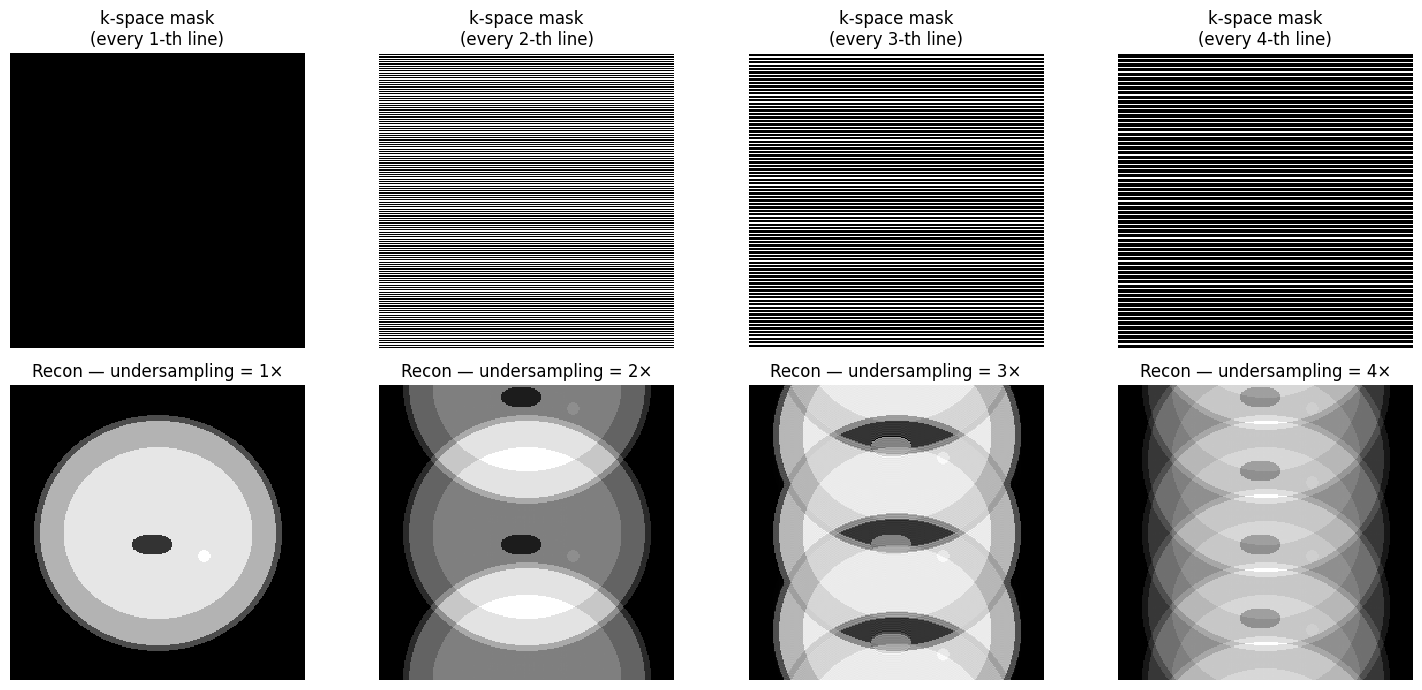

In [11]:
def undersample_phase(img, factor):
    """Keep every `factor`-th line in the phase (vertical) direction.
    A factor of 2 means Δk doubles → FoV halves.
    """
    k = fft2c(img)
    mask = np.zeros_like(k, dtype=float)
    mask[::factor, :] = 1                  # keep every `factor`-th row
    k_under = k * mask
    # The proper interpretation: we acquired with bigger Δk, so we should reconstruct on a smaller FoV.
    # But to *visualize* the aliasing on the original grid, we keep the same grid and just zero unmeasured lines.
    # The reconstructed image then shows the replicated copies overlapping inside the original FoV.
    # (More precisely: with a smaller reconstruction FoV you'd see a single copy already wrapped.)
    return np.abs(ifft2c(k_under)), mask

fig, ax = plt.subplots(2, 4, figsize=(15, 7))
for i, f in enumerate([1, 2, 3, 4]):
    recon, mask = undersample_phase(phantom, f)
    ax[0, i].imshow(mask); ax[0, i].set_title(f'k-space mask\n(every {f}-th line)'); ax[0, i].axis('off')
    ax[1, i].imshow(recon); ax[1, i].set_title(f'Recon — undersampling = {f}×')
    ax[1, i].axis('off')
plt.tight_layout(); plt.show()

Two things to notice:

1. **Ghost copies** of the phantom appear above and below — shifted by $1/\Delta k$ = the new FoV. As we undersample more aggressively, more copies pile in.
2. The ghosts appear **only in the vertical (phase) direction**, never horizontally. That's lecture 11.9's punchline made visible.

### Exercise 10.2 — cylinder + varying FoV

Replicate the configurations from the exercise sheet (subset).

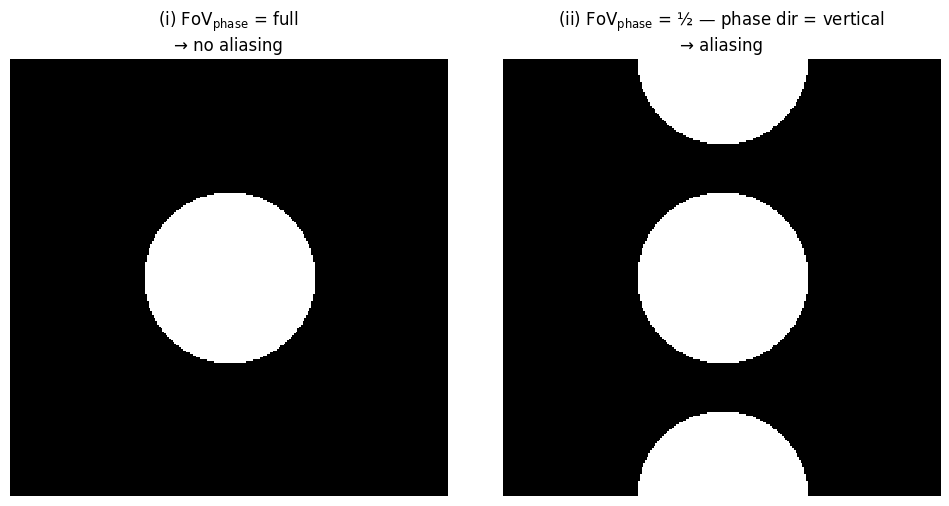

In [12]:
def make_cylinder(N=256, center_xy=(0, 0), radius_px=50):
    img = np.zeros((N, N))
    cy, cx = N//2 + center_xy[1], N//2 + center_xy[0]
    y, x = np.indices((N, N))
    img[(x-cx)**2 + (y-cy)**2 < radius_px**2] = 1.0
    return img

def crop_fov(img, fov_phase_factor=1.0):
    """Simulate a smaller FoV in phase (vertical) direction. fov_phase_factor < 1 = aliasing arises."""
    N = img.shape[0]
    keep = int(N * fov_phase_factor)
    if keep >= N:
        return img.copy()
    # Subsample k-space in phase: equivalent to halving FoV by doubling Δk.
    factor = int(round(1 / fov_phase_factor))
    k = fft2c(img)
    mask = np.zeros_like(k, dtype=float)
    mask[::factor, :] = 1
    return np.abs(ifft2c(k * mask))

# Cylinder of diameter 10 cm = 100 px on a 256-px grid representing ~25.6 cm
# Case (i):  FoV_phase = 10 cm — object fits
# Case (ii): FoV_phase =  5 cm — object too big in phase → aliasing
img_i  = make_cylinder(N=256, center_xy=(0, 0), radius_px=50)
img_ii = make_cylinder(N=256, center_xy=(0, 0), radius_px=50)

# Render with native FoV and with shrunken phase FoV
recon_i  = img_i
recon_ii, _ = undersample_phase(img_ii, 2)  # FoV halved in phase direction

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(recon_i); ax[0].set_title('(i) FoV$_\\text{phase}$ = full\n→ no aliasing'); ax[0].axis('off')
ax[1].imshow(recon_ii); ax[1].set_title('(ii) FoV$_\\text{phase}$ = ½ — phase dir = vertical\n→ aliasing'); ax[1].axis('off')
plt.tight_layout(); plt.show()

**Now read this carefully:** the exercise sheet diagrams (i)–(iv) deal with cropping FoV_read (which in the lecture is *just* a display choice — `FoV_read` does **not** cause aliasing) vs cropping FoV_phase (which does). On a square image where we represent the read direction as horizontal:

- Cropping FoV_read = cropping the horizontal display window. No copies appear.
- Cropping FoV_phase = aliasing in the vertical direction. Copies appear.

**Mini exercise (your turn):** modify the `make_cylinder` call above and put `center_xy=(0, 50)` to shift the cylinder. Which way do the copies pile up? Now do `center_xy=(50, 0)` — what changes?

## 5. Putting it all together — both limitations at once

Combine Limitation 1 (Δk → aliasing) with Limitation 2 (k_max → finite resolution + Gibbs) on the same image. This is what real Cartesian MRI does.

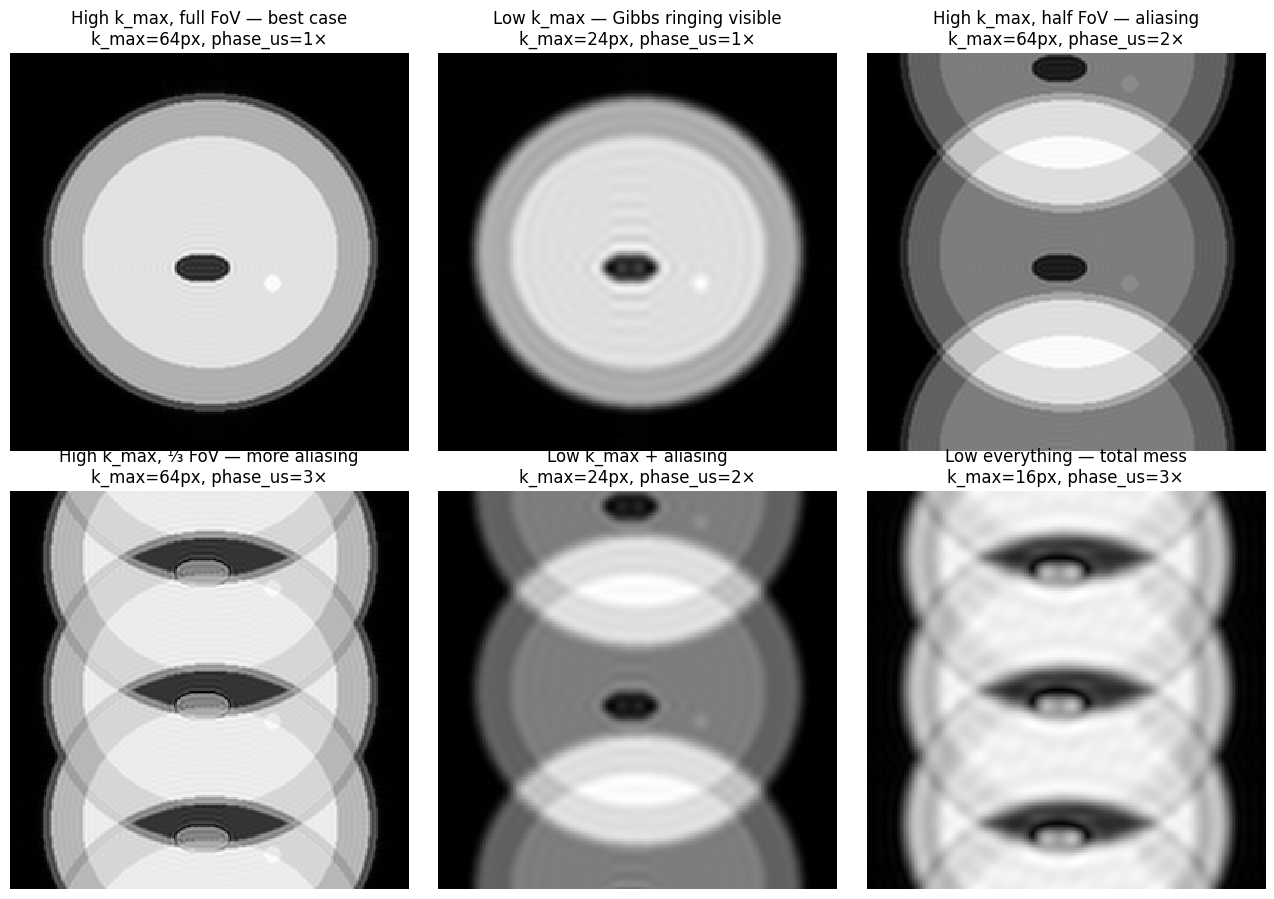

In [13]:
def simulate_cartesian_mri(img, kmax_pixels, phase_undersample=1):
    """Both limitations at once: finite k_max + undersampling in phase direction."""
    N = img.shape[0]
    k = fft2c(img)
    mask = np.zeros_like(k, dtype=float)
    c = N // 2
    # finite k_max box
    mask[c-kmax_pixels:c+kmax_pixels, c-kmax_pixels:c+kmax_pixels] = 1
    # undersample rows (phase direction)
    row_keep = np.zeros(N, dtype=bool)
    row_keep[::phase_undersample] = True
    mask[~row_keep, :] = 0
    return np.abs(ifft2c(k * mask))

fig, ax = plt.subplots(2, 3, figsize=(13, 9))
configs = [(64, 1, 'High k_max, full FoV — best case'),
           (24, 1, 'Low k_max — Gibbs ringing visible'),
           (64, 2, 'High k_max, half FoV — aliasing'),
           (64, 3, 'High k_max, ⅓ FoV — more aliasing'),
           (24, 2, 'Low k_max + aliasing'),
           (16, 3, 'Low everything — total mess')]

for i, (kmax, us, title) in enumerate(configs):
    a = ax[i // 3, i % 3]
    a.imshow(simulate_cartesian_mri(phantom, kmax, us))
    a.set_title(f'{title}\nk_max={kmax}px, phase_us={us}×'); a.axis('off')

plt.tight_layout(); plt.show()

**This is the realistic situation in clinical MRI.** Every parameter dial on the scanner trades off:
- $k_\text{max}$ ↑ ⇒ better resolution, but longer scan time (more lines to acquire)
- $\Delta k$ ↑ ⇒ shorter scan, but smaller FoV ⇒ risk of aliasing
- Filter strength ↑ ⇒ less ringing, but blurrier

Module 4 (Days 23–32) will show how techniques like SENSE, GRAPPA, and compressed sensing let you have your cake and eat it too — undersample k-space *and* avoid aliasing.

## Self-test — try these in your head, then code them up

1. Set `kmax = 4` (very low). Compute the predicted resolution by definition 1 in mm. Does the reconstructed image agree?
2. Pick a `phase_undersample=2` and verify that the ghost copy is exactly *N/2* pixels offset from the true one.
3. Reverse the undersampling direction (cols, not rows). Where do the ghosts go now?
4. The Hanning filter widens the PSF. Can you measure the resulting FWHM and compare it to the boxcar?
5. What happens to Gibbs ringing if the edge isn't a step but a smooth tanh transition? Try it!
